### Introduction to Regression with Neural Networks in TensorFlow

In [1]:
# Import TensorFlow
import tensorflow as tf 
print(tf.__version__)


2.15.0


### Creating data to view and fit

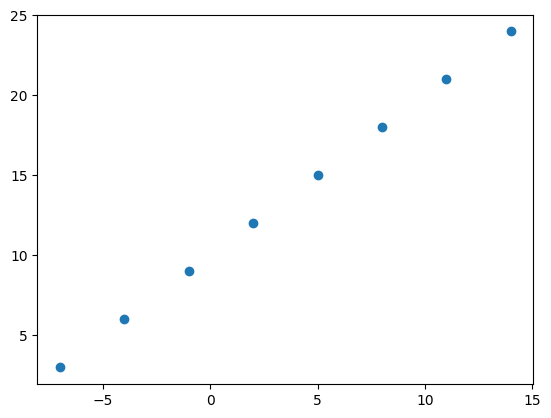

In [2]:
import numpy as np 
import matplotlib.pyplot as plt 

# Create features
X = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0])

# Create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0])

# Visualize it
plt.scatter(X, y)

### Input and Output shapes

In [3]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700])>)

In [4]:
# Turn our Numpy arrays into tensors  with dtype float32
X = tf.cast(tf.constant(X), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [5]:
input_shape = X[0].shape 
output_shape = y[0].shape
input_shape, output_shape

(TensorShape([]), TensorShape([]))

### Steps in modelling with TensorFlow

In [6]:
# Set random seed
tf.random.set_seed(29)

# 1. Create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae, # Mean absolute error
              optimizer=tf.keras.optimizers.SGD(), # Stochastic Gradient Descent
              metrics=["mae"])

# 3. Fit the model
model.fit(tf.expand_dims(X, axis=-1), y, epochs=5)      


Epoch 1/5


1/1 [==============================] - 1s 790ms/step - loss: 19.4809 - mae: 19.4809
Epoch 2/5
1/1 [==============================] - 0s 6ms/step - loss: 19.1996 - mae: 19.1996
Epoch 3/5
1/1 [==============================] - 0s 4ms/step - loss: 18.9184 - mae: 18.9184
Epoch 4/5
1/1 [==============================] - 0s 6ms/step - loss: 18.6371 - mae: 18.6371
Epoch 5/5
1/1 [==============================] - 0s 5ms/step - loss: 18.3559 - mae: 18.3559


In [7]:
# Try and make a prediction using our model
model.predict([17.0])

1/1 [==============================] - 0s 105ms/step


array([[-17.295208]], dtype=float32)

## Improving our model

In [8]:
# Let's rebuild our model

# 1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

# 3. Fit the model (this time with 100 epochs)
model.fit(tf.expand_dims(X, -1), y, epochs=100)

Epoch 1/100
1/1 [==============================] - 0s 291ms/step - loss: 17.2390 - mae: 17.2390
Epoch 2/100
1/1 [==============================] - 0s 5ms/step - loss: 16.9577 - mae: 16.9577
Epoch 3/100
1/1 [==============================] - 0s 5ms/step - loss: 16.6765 - mae: 16.6765
Epoch 4/100
1/1 [==============================] - 0s 5ms/step - loss: 16.3952 - mae: 16.3952
Epoch 5/100
1/1 [==============================] - 0s 4ms/step - loss: 16.1140 - mae: 16.1140
Epoch 6/100
1/1 [==============================] - 0s 5ms/step - loss: 15.8327 - mae: 15.8327
Epoch 7/100
1/1 [==============================] - 0s 5ms/step - loss: 15.5515 - mae: 15.5515
Epoch 8/100
1/1 [==============================] - 0s 5ms/step - loss: 15.2702 - mae: 15.2702
Epoch 9/100
1/1 [==============================] - 0s 4ms/step - loss: 14.9890 - mae: 14.9890
Epoch 10/100
1/1 [==============================] - 0s 4ms/step - loss: 14.7714 - mae: 14.7714
Epoch 11/100
1/1 [==============================] - 0s 6m

In [9]:
# Let's see if our model's prediction has improved
model.predict([17.0])

1/1 [==============================] - 0s 68ms/step


array([[29.49926]], dtype=float32)

In [10]:
# Let's rebuild our model

# 1. Create the model
model = tf.keras.Sequential([
   tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["mae"])

# 3. Fit the model (this time with 100 epochs)
model.fit(tf.expand_dims(X, -1), y, epochs=100)

Epoch 1/100
1/1 [==============================] - 0s 364ms/step - loss: 8.4699 - mae: 8.4699
Epoch 2/100
1/1 [==============================] - 0s 5ms/step - loss: 8.4654 - mae: 8.4654
Epoch 3/100
1/1 [==============================] - 0s 5ms/step - loss: 8.4609 - mae: 8.4609
Epoch 4/100
1/1 [==============================] - 0s 5ms/step - loss: 8.4564 - mae: 8.4564
Epoch 5/100
1/1 [==============================] - 0s 5ms/step - loss: 8.4519 - mae: 8.4519
Epoch 6/100
1/1 [==============================] - 0s 5ms/step - loss: 8.4474 - mae: 8.4474
Epoch 7/100
1/1 [==============================] - 0s 4ms/step - loss: 8.4429 - mae: 8.4429
Epoch 8/100
1/1 [==============================] - 0s 5ms/step - loss: 8.4384 - mae: 8.4384
Epoch 9/100
1/1 [==============================] - 0s 5ms/step - loss: 8.4339 - mae: 8.4339
Epoch 10/100
1/1 [==============================] - 0s 5ms/step - loss: 8.4294 - mae: 8.4294
Epoch 11/100
1/1 [==============================] - 0s 4ms/step - loss: 8.424

In [11]:
model.predict([18.0])

1/1 [==============================] - 0s 71ms/step


array([[27.769205]], dtype=float32)

In [12]:
# Let's see if we can make another to improve our model

# 1. Create the model (this time with an extra hidden layer with 100 hidden units)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss="mae",
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mae"])

# 3. Fit the model
model.fit(tf.expand_dims(X, -1), y, epochs=100)

Epoch 1/100
1/1 [==============================] - 1s 509ms/step - loss: 11.9409 - mae: 11.9409
Epoch 2/100
1/1 [==============================] - 0s 5ms/step - loss: 11.2949 - mae: 11.2949
Epoch 3/100
1/1 [==============================] - 0s 5ms/step - loss: 10.6386 - mae: 10.6386
Epoch 4/100
1/1 [==============================] - 0s 6ms/step - loss: 9.9702 - mae: 9.9702
Epoch 5/100
1/1 [==============================] - 0s 5ms/step - loss: 9.2869 - mae: 9.2869
Epoch 6/100
1/1 [==============================] - 0s 5ms/step - loss: 8.5850 - mae: 8.5850
Epoch 7/100
1/1 [==============================] - 0s 5ms/step - loss: 7.8614 - mae: 7.8614
Epoch 8/100
1/1 [==============================] - 0s 5ms/step - loss: 7.1131 - mae: 7.1131
Epoch 9/100
1/1 [==============================] - 0s 5ms/step - loss: 6.8555 - mae: 6.8555
Epoch 10/100
1/1 [==============================] - 0s 5ms/step - loss: 7.1775 - mae: 7.1775
Epoch 11/100
1/1 [==============================] - 0s 5ms/step - loss:

In [13]:
# Let's try to make a prediction
model.predict([17.0])

1/1 [==============================] - 0s 76ms/step


array([[27.494]], dtype=float32)

### Evaluating a model 

In practice, a typical workflow you'll go through when building neural networks is:

```
Built a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it.....
```

In [14]:
# Make a bigger dataset
X = tf.range(-100, 100, 4)
X


<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96])>

In [15]:
# Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

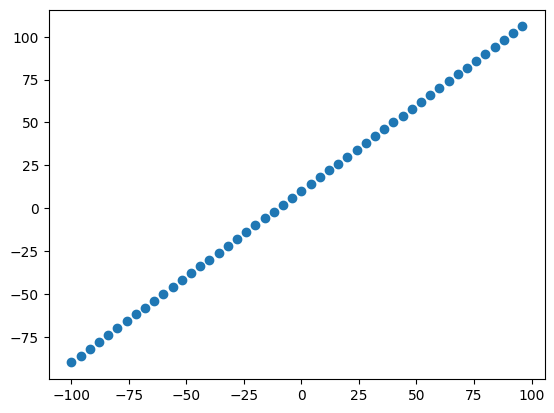

In [16]:
# Visualize the data 
import matplotlib.pyplot as plt

plt.scatter(X, y)

### The 3 sets...

* **Training set** - the model learns from this data, which is typically 70-80% of the total data you have available.
* **Validation set** - the model gets tuned on this data, which is typically 10-15% of the data available.
* **Test set** - the model gets evaluated on this data to test what is has learned, this set is typically 10-15% of the total data available.

In [17]:
# Check the length of how many samples we have
len(X)

50

In [18]:
# Split the data into train and test sets
X_train = X[:40] # First 40 are training samples (80% of the data)
y_train = y[:40]

X_test = X[40:] # last 10 are testing samples (20% of the data)
y_test = y[40:]

len(X_train), len(X_test), len(X_test), len(y_test)

(40, 10, 10, 10)

### Visualizing the data
Now we've got our data in training and test sets...let's visualize it again!

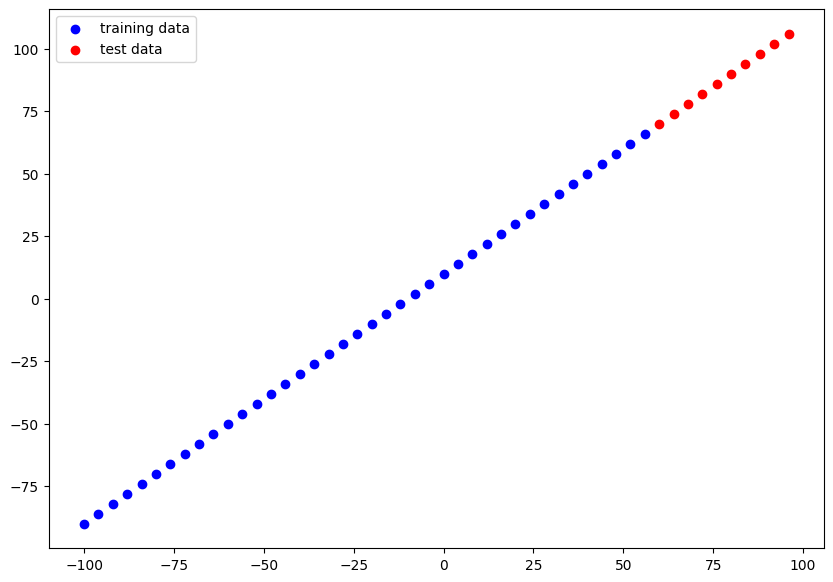

In [19]:
plt.figure(figsize=(10, 7))
# Plot training data in blue
plt.scatter(X_train, y_train, c="b", label="training data")

# Plot test data in red
plt.scatter(X_test, y_test, c="r", label="test data")

# Legend
plt.legend();

In [20]:
# 1. Create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(20, input_shape=[1], name="input_shape"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="model_1")

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

In [21]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_shape (Dense)         (None, 20)                40        
                                                                 
 output_layer (Dense)        (None, 1)                 21        
                                                                 
Total params: 61 (244.00 Byte)
Trainable params: 61 (244.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
# Let's fit the model with training data
model.fit(tf.expand_dims(X, -1), y, epochs=100, verbose=2)

Epoch 1/100
2/2 - 0s - loss: 57.2498 - mae: 57.2498 - 324ms/epoch - 162ms/step
Epoch 2/100
2/2 - 0s - loss: 29.4856 - mae: 29.4856 - 5ms/epoch - 2ms/step
Epoch 3/100
2/2 - 0s - loss: 37.2979 - mae: 37.2979 - 4ms/epoch - 2ms/step
Epoch 4/100
2/2 - 0s - loss: 33.0484 - mae: 33.0484 - 5ms/epoch - 3ms/step
Epoch 5/100
2/2 - 0s - loss: 10.0201 - mae: 10.0201 - 5ms/epoch - 3ms/step
Epoch 6/100
2/2 - 0s - loss: 19.0956 - mae: 19.0956 - 5ms/epoch - 3ms/step
Epoch 7/100
2/2 - 0s - loss: 29.5589 - mae: 29.5589 - 5ms/epoch - 2ms/step
Epoch 8/100
2/2 - 0s - loss: 15.8435 - mae: 15.8435 - 5ms/epoch - 2ms/step
Epoch 9/100
2/2 - 0s - loss: 21.7418 - mae: 21.7418 - 5ms/epoch - 2ms/step
Epoch 10/100
2/2 - 0s - loss: 19.1403 - mae: 19.1403 - 5ms/epoch - 2ms/step
Epoch 11/100
2/2 - 0s - loss: 16.2552 - mae: 16.2552 - 4ms/epoch - 2ms/step
Epoch 12/100
2/2 - 0s - loss: 29.0240 - mae: 29.0240 - 5ms/epoch - 2ms/step
Epoch 13/100
2/2 - 0s - loss: 25.4667 - mae: 25.4667 - 5ms/epoch - 3ms/step
Epoch 14/100
2/2 

In [23]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_shape (Dense)         (None, 20)                40        
                                                                 
 output_layer (Dense)        (None, 1)                 21        
                                                                 
Total params: 61 (244.00 Byte)
Trainable params: 61 (244.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


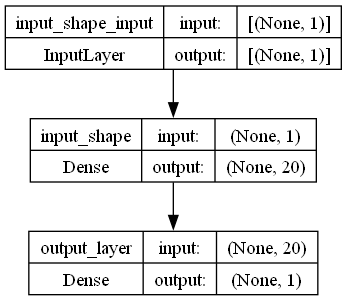

In [24]:
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

### Visualizing our model's predictions

To visualize predictions, it's a good idea to plot them against the ground truth labels.
Often you'll see this in the form of y_test, or y_true versus y_pred (ground truth versus your model's predictions).


In [25]:
# Make some predictions
y_pred = model.predict(X_test)
y_pred

1/1 [==============================] - 0s 57ms/step


array([[42.087826],
       [44.79773 ],
       [47.507633],
       [50.21754 ],
       [52.927444],
       [55.63735 ],
       [58.34725 ],
       [61.057156],
       [63.767056],
       [66.47696 ]], dtype=float32)

In [26]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

In [27]:
# Let's create a plotting function
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=y_pred):

#Plots training data, test data and compares predictions to ground truth labels. 

    plt.figure(figsize=(10, 7))
    # plotting training data in blue
    plt.scatter(train_data, train_labels, c="b", label="Training data")
    # Plot testing data in green
    plt.scatter(test_data, test_labels, c="g", label="Testing data")
    # Plot model's predictions in red
    plt.scatter(test_data, predictions, c="r", label="Predictions")
    # Show the legend
    plt.legend();

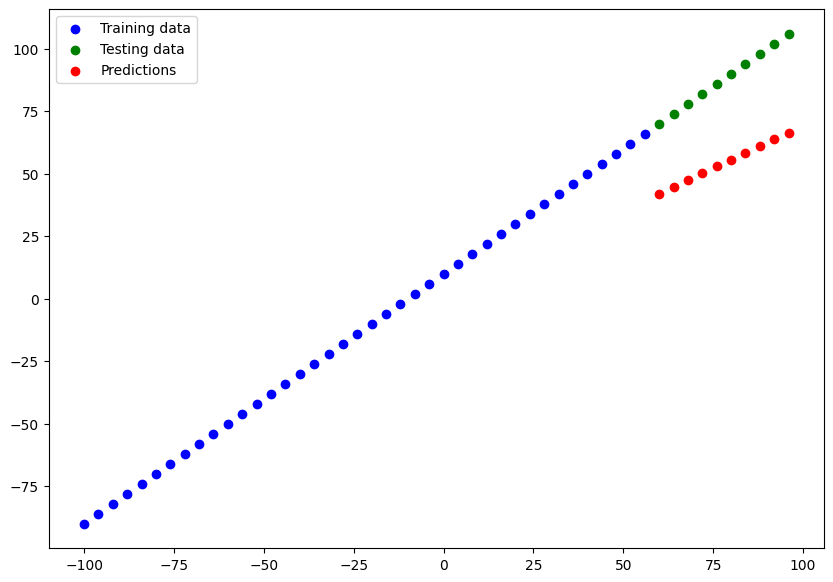

In [28]:
plot_predictions(train_data=X_train,
                 train_labels=y_train,
                 test_data=X_test,
                 test_labels=y_test,
                 predictions=y_pred)

### Evluating our model's predictions with regression evaluation metrics

Depending on the problem you're working on, there will be different evaluation metrics to evaluate your model's performance.

Since we're working on a regression, two of the main metrics:
* MAE - mean absolute error, "on average, how wrong is each of my model's predicitons"
* MSE - mean square error, "square the average errors"

In [29]:
# Evaluate the model on the test
model.evaluate(X_test, y_test)

1/1 [==============================] - 0s 146ms/step - loss: 33.7176 - mae: 33.7176


[33.71760177612305, 33.71760177612305]

In [30]:
# Calculate the mean absolute error 
mae = tf.metrics.mean_absolute_error(y_true=y_test,
                                     y_pred=tf.constant(y_pred))
mae

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([45.912174, 43.20227 , 40.492367, 37.78246 , 35.072556, 32.36265 ,
       29.652746, 26.942844, 24.232944, 21.52304 ], dtype=float32)>

In [31]:
tf.constant(y_pred)

<tf.Tensor: shape=(10, 1), dtype=float32, numpy=
array([[42.087826],
       [44.79773 ],
       [47.507633],
       [50.21754 ],
       [52.927444],
       [55.63735 ],
       [58.34725 ],
       [61.057156],
       [63.767056],
       [66.47696 ]], dtype=float32)>

In [32]:
y_test

<tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106])>

In [33]:
tf.squeeze(y_pred)

<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([42.087826, 44.79773 , 47.507633, 50.21754 , 52.927444, 55.63735 ,
       58.34725 , 61.057156, 63.767056, 66.47696 ], dtype=float32)>

In [34]:
# Calculate the mean absolute error 
mae = tf.metrics.mean_absolute_error(y_true=y_test,
                                     y_pred=tf.squeeze(y_pred))
mae

<tf.Tensor: shape=(), dtype=float32, numpy=33.7176>

In [35]:
# Calculate the mean square error
mse = tf.metrics.mean_squared_error(y_true=y_test,
                                    y_pred=tf.squeeze(y_pred))
mse

<tf.Tensor: shape=(), dtype=float32, numpy=1150.6078>

In [36]:
# Make some functions to reuse MAE and MSE

def mae(y_true, y_pred):
    return tf.metrics.mean_absolute_error(y_true=y_true,
                                          y_pred=tf.squeeze(y_pred))
    
def mse(y_true, y_pred):
    return tf.metrics.mean_squared_error(y_true=y_true,
                                         y_pred=tf.squeeze(y_pred))

### Running experiments to improve our model

1. Get more data = get more examples for your model to train on (more opportunities to learn patters or relationships between features and labels).

2. Make your model larger (using a more complex model) - this might come in the form of more layers or more hidden units in each layer.

3. Train for longer - give your model more of a chance to find patters in the data.

Let's do 3 modelling experiments:

1. `model_1` - same as the original model, 1 layer, trained for 100 epochs
2. `model_2` - 2 layers, trained for 100 epochs
3. `model_3` - 2 layers, trained for 500 epochs

In [37]:
 X_train, y_train

(<tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56])>,
 <tf.Tensor: shape=(40,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66])>)

**Build model_1**

In [38]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

# 3. Fit the model
model_1.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100)

Epoch 1/100


2/2 [==============================] - 0s 8ms/step - loss: 19.4803 - mae: 19.4803
Epoch 2/100
2/2 [==============================] - 0s 4ms/step - loss: 8.1676 - mae: 8.1676
Epoch 3/100
2/2 [==============================] - 0s 3ms/step - loss: 10.2336 - mae: 10.2336
Epoch 4/100
2/2 [==============================] - 0s 3ms/step - loss: 12.6106 - mae: 12.6106
Epoch 5/100
2/2 [==============================] - 0s 6ms/step - loss: 11.6592 - mae: 11.6592
Epoch 6/100
2/2 [==============================] - 0s 4ms/step - loss: 10.7663 - mae: 10.7663
Epoch 7/100
2/2 [==============================] - 0s 4ms/step - loss: 8.7917 - mae: 8.7917
Epoch 8/100
2/2 [==============================] - 0s 4ms/step - loss: 8.1129 - mae: 8.1129
Epoch 9/100
2/2 [==============================] - 0s 4ms/step - loss: 18.6722 - mae: 18.6722
Epoch 10/100
2/2 [==============================] - 0s 3ms/step - loss: 14.4742 - mae: 14.4742
Epoch 11/100
2/2 [==============================] - 0s 4ms/step - loss: 11.80

1/1 [==============================] - 0s 51ms/step


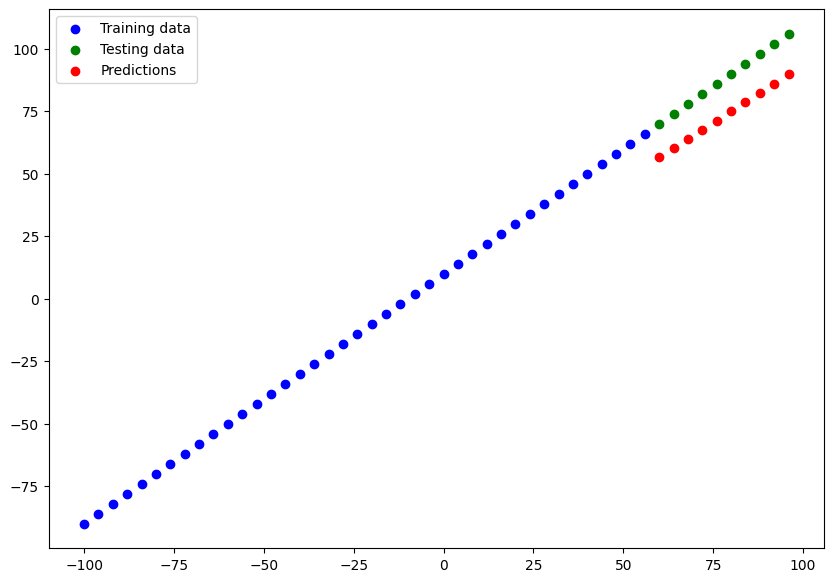

In [39]:
# Make and plot predictions for model_1
y_preds_1 = model_1.predict(X_test)
plot_predictions(predictions=y_preds_1)

In [40]:
y_preds_1 = tf.squeeze(y_preds_1)

In [41]:
# Caclualte model_1 evaluation metrics
mae_1 = mae(y_test, y_preds_1)
mse_1 = mse(y_test, y_preds_1)
mae_1, mse_1

(<tf.Tensor: shape=(), dtype=float32, numpy=14.856279>,
 <tf.Tensor: shape=(), dtype=float32, numpy=221.5323>)

**Build model_2**

In [42]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mse"])

# 3. Fit the model
model_2.fit(tf.expand_dims(X_train,axis=-1), y_train, epochs=100)

Epoch 1/100


2/2 [==============================] - 0s 7ms/step - loss: 50.7246 - mse: 3979.8621
Epoch 2/100
2/2 [==============================] - 0s 4ms/step - loss: 28.1066 - mse: 1023.1646
Epoch 3/100
2/2 [==============================] - 0s 4ms/step - loss: 32.8428 - mse: 1631.6814
Epoch 4/100
2/2 [==============================] - 0s 3ms/step - loss: 29.2298 - mse: 1269.2708
Epoch 5/100
2/2 [==============================] - 0s 4ms/step - loss: 15.8139 - mse: 328.5940
Epoch 6/100
2/2 [==============================] - 0s 4ms/step - loss: 12.5239 - mse: 204.1027
Epoch 7/100
2/2 [==============================] - 0s 4ms/step - loss: 11.7753 - mse: 171.5398
Epoch 8/100
2/2 [==============================] - 0s 3ms/step - loss: 12.1142 - mse: 204.6093
Epoch 9/100
2/2 [==============================] - 0s 4ms/step - loss: 38.1122 - mse: 2246.7603
Epoch 10/100
2/2 [==============================] - 0s 4ms/step - loss: 25.6841 - mse: 926.6545
Epoch 11/100
2/2 [==============================] - 0s 4

1/1 [==============================] - 0s 65ms/step


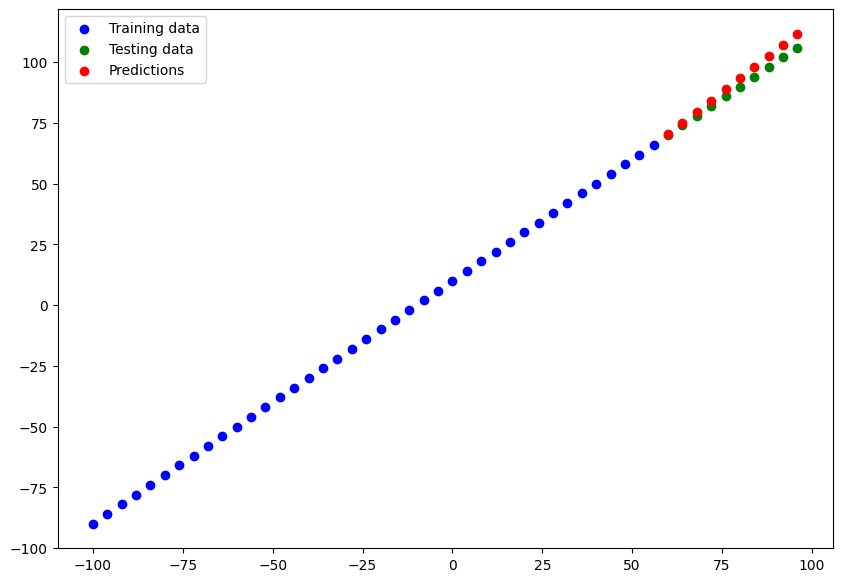

In [43]:
# Make and plot predictions of model_2
y_preds_2 = model_2.predict(X_test)
plot_predictions(predictions=y_preds_2)

In [44]:
# Calculte model_2 evaluation metrics
mae_2 = mae(y_test, y_preds_2)
mse_2 = mse(y_test, y_preds_2)
mae_2, mse_2

(<tf.Tensor: shape=(), dtype=float32, numpy=3.1029334>,
 <tf.Tensor: shape=(), dtype=float32, numpy=12.429945>)

**Build model_3**

In [45]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

# 3. Fit the model
model_3.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=500)

Epoch 1/500
2/2 [==============================] - 0s 8ms/step - loss: 70.8039 - mae: 70.8039
Epoch 2/500
2/2 [==============================] - 0s 5ms/step - loss: 31.5246 - mae: 31.5246
Epoch 3/500
2/2 [==============================] - 0s 5ms/step - loss: 22.1651 - mae: 22.1651
Epoch 4/500
2/2 [==============================] - 0s 4ms/step - loss: 12.8430 - mae: 12.8430
Epoch 5/500
2/2 [==============================] - 0s 4ms/step - loss: 15.8756 - mae: 15.8756
Epoch 6/500
2/2 [==============================] - 0s 4ms/step - loss: 12.5804 - mae: 12.5804
Epoch 7/500
2/2 [==============================] - 0s 3ms/step - loss: 11.8377 - mae: 11.8377
Epoch 8/500
2/2 [==============================] - 0s 4ms/step - loss: 12.8891 - mae: 12.8891
Epoch 9/500
2/2 [==============================] - 0s 4ms/step - loss: 33.8369 - mae: 33.8369
Epoch 10/500
2/2 [==============================] - 0s 4ms/step - loss: 23.1531 - mae: 23.1531
Epoch 11/500
2/2 [==============================] - 0s 4ms/

1/1 [==============================] - 0s 56ms/step


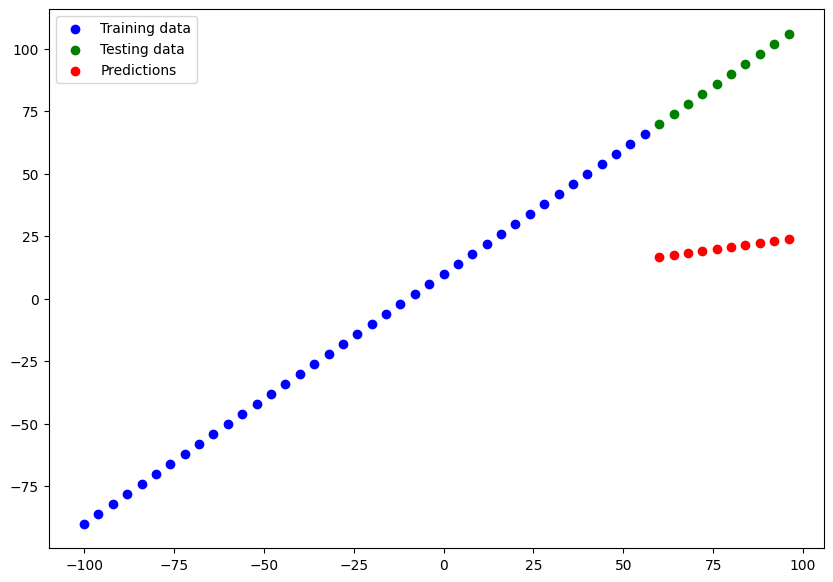

In [46]:
# Make and plot same predictions
y_preds_3 = model_3.predict(X_test)
plot_predictions(predictions=y_preds_3)

In [47]:
# Calculate model_3 evaluation metrics
mae_3 = mae(y_test, y_preds_3)
mse_3 = mse(y_test, y_preds_3)
mae_3, mse_3

(<tf.Tensor: shape=(), dtype=float32, numpy=67.64154>,
 <tf.Tensor: shape=(), dtype=float32, numpy=4659.4624>)

### Comparing the results of our experiments
We've run a few experiments, let's compare the results

In [48]:
# let's compare our model's results using a pandas DataFrame
import pandas as pd

model_results = [["model_1", mae_1.numpy(), mse_1.numpy()],
                 ["model_2", mae_2.numpy(), mse_2.numpy()],
                 ["model_3", mae_3.numpy(), mse_3.numpy()]]

all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_1,14.856279,221.532303
1,model_2,3.102933,12.429945
2,model_3,67.641541,4659.462402


In [49]:
model_2.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                20        
                                                                 
 dense_7 (Dense)             (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Saving our models

In [50]:
# Save model using the SavedModel format
model_2.save("best_model_SavedModel_format")

INFO:tensorflow:Assets written to: best_model_SavedModel_format\assets


INFO:tensorflow:Assets written to: best_model_SavedModel_format\assets


In [51]:
# Save model using the HDF5 format
model_2.save("best_model_HDF5_format.h5")

c:\Users\Priyesh\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


### Loading in a saved model

In [52]:
# Load in the SavedModel format model
loaded_SavedModel_format = tf.keras.models.load_model("best_model_SavedModel_format")
loaded_SavedModel_format.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                20        
                                                                 
 dense_7 (Dense)             (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [53]:
model_2.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                20        
                                                                 
 dense_7 (Dense)             (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [54]:
# Compare model_2 predictions with SavedModel format model predictions
model_2_preds = model_2.predict(X_test)
loaded_SavedModel_format_preds = loaded_SavedModel_format.predict(X_test)

model_2_preds.squeeze() == loaded_SavedModel_format_preds.squeeze()

1/1 [==============================] - 0s 72ms/step


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [55]:
mae(y_true=y_test, y_pred=model_2_preds) == mae(y_true=y_test, y_pred=loaded_SavedModel_format_preds)

<tf.Tensor: shape=(), dtype=bool, numpy=True>

In [56]:
# Load in a model using the .h5 format
loaded_h5_model = tf.keras.models.load_model("best_model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                20        
                                                                 
 dense_7 (Dense)             (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [57]:
model_2.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 10)                20        
                                                                 
 dense_7 (Dense)             (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [58]:
# Check to see if loaded .h5 model predictions match model_2
model_2_preds = model_2.predict(X_test)
loaded_h5_model_preds = loaded_h5_model.predict(X_test)
model_2_preds == loaded_h5_model_preds

1/1 [==============================] - 0s 58ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

### A larger example 

In [59]:
# Import required libraries
import tensorflow as tf 
import pandas as pd 
import matplotlib.pyplot as plt 

In [60]:
# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


Data Preprocessing 

In [61]:
# Converting objects into numbers
insurance.sex = insurance.sex.apply(lambda x : 1 if x == "male" else 0)
insurance.sex

0       0
1       1
2       1
3       1
4       1
       ..
1333    1
1334    0
1335    0
1336    0
1337    0
Name: sex, Length: 1338, dtype: int64

In [62]:
insurance.smoker = insurance.smoker.apply(lambda x : 1 if x == "yes" else 0)
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [63]:
insurance.sex.unique(), insurance.smoker.unique()

(array([0, 1], dtype=int64), array([1, 0], dtype=int64))

In [64]:
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [65]:
# Now One-hot encoding our DataFrame for region columns
insurance_one_hot = pd.get_dummies(insurance, dtype=int)
insurance_one_hot.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [66]:
# Creating features and labels
X = insurance_one_hot.drop(["charges"], axis=1)
y = insurance_one_hot["charges"]

In [67]:
# View X
X.head()

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,0,1
1,18,1,33.770,1,0,0,0,1,0
2,28,1,33.000,3,0,0,0,1,0
3,33,1,22.705,0,0,0,1,0,0
4,32,1,28.880,0,0,0,1,0,0


In [68]:
# View y 
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [69]:
# Create training and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 , random_state=42)
len(X), len(X_train), len(X_test) 

(1338, 1070, 268)

In [70]:
# Build a neural network 
tf.random.set_seed(42)

# 1. Create a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer=tf.keras.optimizers.SGD(),
                        metrics=["mae"])

# 3. Fit the model
insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 [==============================] - 0s 1ms/step - loss: 8619.4307 - mae: 8619.4307
Epoch 2/100
34/34 [==============================] - 0s 2ms/step - loss: 7880.3467 - mae: 7880.3467
Epoch 3/100
34/34 [==============================] - 0s 1ms/step - loss: 7606.9243 - mae: 7606.9243
Epoch 4/100
34/34 [==============================] - 0s 1ms/step - loss: 7600.9570 - mae: 7600.9570
Epoch 5/100
34/34 [==============================] - 0s 1ms/step - loss: 7745.0684 - mae: 7745.0684
Epoch 6/100
34/34 [==============================] - 0s 1ms/step - loss: 7594.0928 - mae: 7594.0928
Epoch 7/100
34/34 [==============================] - 0s 1ms/step - loss: 7583.4351 - mae: 7583.4351
Epoch 8/100
34/34 [==============================] - 0s 1ms/step - loss: 7839.6685 - mae: 7839.6685
Epoch 9/100
34/34 [==============================] - 0s 1ms/step - loss: 7645.6919 - mae: 7645.6919
Epoch 10/100
34/34 [==============================] - 0s 1ms/step - loss: 7741.4434 - mae: 7741.4434

In [71]:
# Check the results of the insurance model on the test data 
insurance_model.evaluate(X_test, y_test)

9/9 [==============================] - 0s 1ms/step - loss: 7517.1123 - mae: 7517.1123


[7517.1123046875, 7517.1123046875]

In [72]:
y_train.median(), y_train.mean()

(9575.4421, 13346.089736364485)

Right mow it looks like our model isn't performing too well.. let's try and improve it

To (try) improve our model, we'll run 2 experiments:
1. Add an extra layer with more hidden units and use the adam optimizer
2. Train for longer

In [73]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile  the model
insurance_model_2.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

# 3. Fit the model
insurance_model_2.fit(X_train, y_train, epochs=100, verbose=1)

Epoch 1/100
34/34 [==============================] - 1s 1ms/step - loss: 13278.3281 - mae: 13278.3281
Epoch 2/100
34/34 [==============================] - 0s 1ms/step - loss: 13114.7520 - mae: 13114.7520
Epoch 3/100
34/34 [==============================] - 0s 1ms/step - loss: 12773.2607 - mae: 12773.2607
Epoch 4/100
34/34 [==============================] - 0s 1ms/step - loss: 12101.5889 - mae: 12101.5889
Epoch 5/100
34/34 [==============================] - 0s 1ms/step - loss: 10976.2891 - mae: 10976.2891
Epoch 6/100
34/34 [==============================] - 0s 1ms/step - loss: 9533.1582 - mae: 9533.1582
Epoch 7/100
34/34 [==============================] - 0s 1ms/step - loss: 8193.7871 - mae: 8193.7871
Epoch 8/100
34/34 [==============================] - 0s 1ms/step - loss: 7532.3281 - mae: 7532.3281
Epoch 9/100
34/34 [==============================] - 0s 1ms/step - loss: 7417.7031 - mae: 7417.7031
Epoch 10/100
34/34 [==============================] - 0s 1ms/step - loss: 7399.3857 - mae:

In [74]:
# Evaluate the larger model
insurance_model_2.evaluate(X_test, y_test)

9/9 [==============================] - 0s 2ms/step - loss: 5981.4331 - mae: 5981.4331


[5981.43310546875, 5981.43310546875]

In [75]:
# Set random set
tf.random.set_seed(42)


# 1. Create the model (same as above)
insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_3.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

# 3. Fit the model
history = insurance_model_3.fit(X_train, y_train, epochs=200)

Epoch 1/200
34/34 [==============================] - 1s 2ms/step - loss: 13290.1445 - mae: 13290.1445
Epoch 2/200
34/34 [==============================] - 0s 1ms/step - loss: 13079.2627 - mae: 13079.2627
Epoch 3/200
34/34 [==============================] - 0s 2ms/step - loss: 12660.1123 - mae: 12660.1123
Epoch 4/200
34/34 [==============================] - 0s 2ms/step - loss: 11866.4092 - mae: 11866.4092
Epoch 5/200
34/34 [==============================] - 0s 2ms/step - loss: 10599.7725 - mae: 10599.7725
Epoch 6/200
34/34 [==============================] - 0s 1ms/step - loss: 9085.0254 - mae: 9085.0254
Epoch 7/200
34/34 [==============================] - 0s 2ms/step - loss: 7842.3457 - mae: 7842.3457
Epoch 8/200
34/34 [==============================] - 0s 2ms/step - loss: 7406.8779 - mae: 7406.8779
Epoch 9/200
34/34 [==============================] - 0s 2ms/step - loss: 7356.3306 - mae: 7356.3306
Epoch 10/200
34/34 [==============================] - 0s 2ms/step - loss: 7339.8872 - mae:

In [76]:
# Evaluate our third model
insurance_model_3.evaluate(X_test, y_test)

9/9 [==============================] - 0s 2ms/step - loss: 3455.8140 - mae: 3455.8140


[3455.81396484375, 3455.81396484375]

Text(0.5, 0, 'epochs')

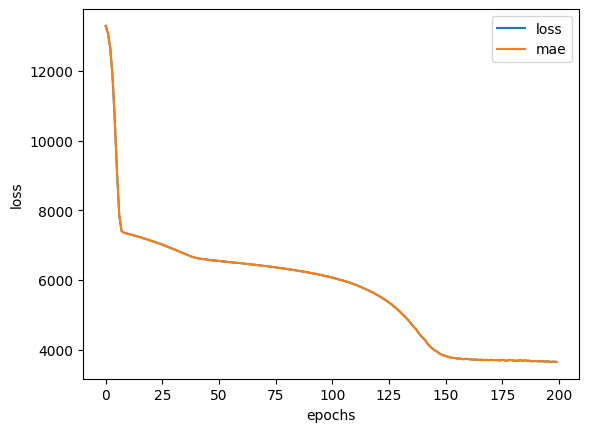

In [77]:
# Plot history (also known as a loss curve or a training curve)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

## Preprocessing data (normalization and standardization)
In terms of scaling values, neural networks tend to prefer normalization.
If you're not sure on which to use, you could try both and see which performs better.

In [78]:
X

,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,0,0,0,1
1,18,1,33.770,1,0,0,0,1,0
2,28,1,33.000,3,0,0,0,1,0
3,33,1,22.705,0,0,0,1,0,0
4,32,1,28.880,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,0,1,0,0
1334,18,0,31.920,0,0,1,0,0,0
1335,18,0,36.850,0,0,0,0,1,0
1336,21,0,25.800,0,0,0,0,0,1


<Axes: ylabel='Frequency'>

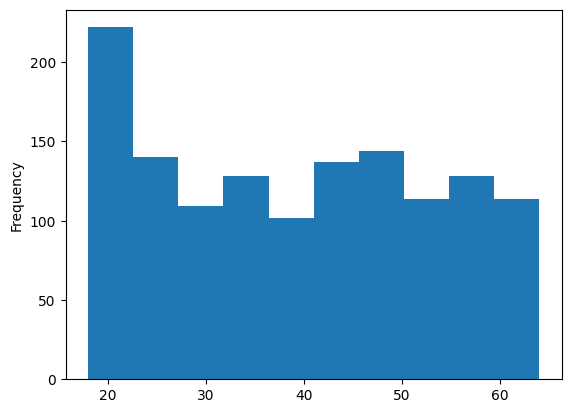

In [79]:
X['age'].plot(kind="hist")

<Axes: ylabel='Frequency'>

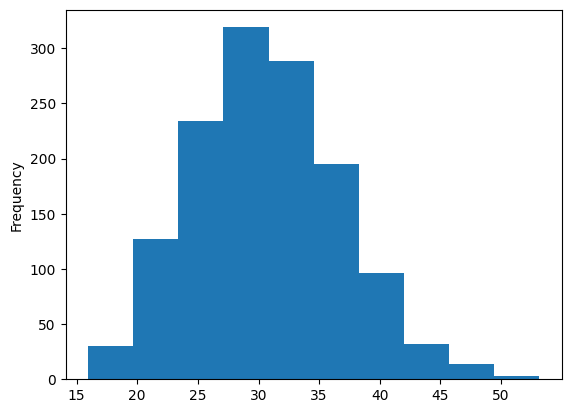

In [80]:
X["bmi"].plot(kind="hist")

In [81]:
X["children"].value_counts()

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64

In [82]:
# Preprocessing 
import pandas as pd 
import matplotlib.pyplot as plt
import tensorflow as tf 

# Read in the insurance dataframe
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [83]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Create a column transformer
ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]), # turn all values in range of 0 to 1
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
)

# Create x & y
X = insurance.drop("charges", axis=1 )
y = insurance["charges"]

# Built our train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the column transformer to our training data
ct.fit(X_train)

# Transform training and test data with normalization (MinMaxScaler) and OneHotEncoder
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test) 

In [84]:
# What does our dat look like now?
X_train.loc[0]

age                19
sex            female
bmi              27.9
children            0
smoker            yes
region      southwest
Name: 0, dtype: object

In [85]:
X_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [86]:
X_train.shape, X_train_normal.shape

((1070, 6), (1070, 11))

In [87]:
# Build a neural network model to fit on our normalized data
tf.random.set_seed(42)

# 1. Create the model
insurance_model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_4.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

# 3. Fit the model
insurance_model_4.fit(X_train_normal, y_train, epochs=100)

Epoch 1/100


34/34 [==============================] - 1s 2ms/step - loss: 13343.5596 - mae: 13343.5596
Epoch 2/100
34/34 [==============================] - 0s 2ms/step - loss: 13334.9893 - mae: 13334.9893
Epoch 3/100
34/34 [==============================] - 0s 2ms/step - loss: 13313.0391 - mae: 13313.0391
Epoch 4/100
34/34 [==============================] - 0s 1ms/step - loss: 13267.6270 - mae: 13267.6270
Epoch 5/100
34/34 [==============================] - 0s 2ms/step - loss: 13188.4678 - mae: 13188.4678
Epoch 6/100
34/34 [==============================] - 0s 2ms/step - loss: 13064.9912 - mae: 13064.9912
Epoch 7/100
34/34 [==============================] - 0s 2ms/step - loss: 12887.0537 - mae: 12887.0537
Epoch 8/100
34/34 [==============================] - 0s 2ms/step - loss: 12644.4531 - mae: 12644.4531
Epoch 9/100
34/34 [==============================] - 0s 2ms/step - loss: 12326.8916 - mae: 12326.8916
Epoch 10/100
34/34 [==============================] - 0s 1ms/step - loss: 11929.4697 - mae: 11

In [88]:
# Evaluate our insurance model trained on normalized data 
insurance_model_4.evaluate(X_test_normal, y_test)

9/9 [==============================] - 0s 2ms/step - loss: 3439.7332 - mae: 3439.7332


[3439.733154296875, 3439.733154296875]

In [104]:
# Adding more layers and neurons

# Setting random seed
tf.random.set_seed(42)

# 1. Model Building
insurance_model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_5.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

history = insurance_model_5.fit(X_train_normal, y_train, epochs=200)

Epoch 1/200
34/34 [==============================] - 1s 2ms/step - loss: 13343.6797 - mae: 13343.6797
Epoch 2/200
34/34 [==============================] - 0s 2ms/step - loss: 13313.6289 - mae: 13313.6289
Epoch 3/200
34/34 [==============================] - 0s 1ms/step - loss: 13105.0186 - mae: 13105.0186
Epoch 4/200
34/34 [==============================] - 0s 1ms/step - loss: 12264.9893 - mae: 12264.9893
Epoch 5/200
34/34 [==============================] - 0s 2ms/step - loss: 10292.1875 - mae: 10292.1875
Epoch 6/200
34/34 [==============================] - 0s 1ms/step - loss: 8360.5508 - mae: 8360.5508
Epoch 7/200
34/34 [==============================] - 0s 1ms/step - loss: 7883.6001 - mae: 7883.6001
Epoch 8/200
34/34 [==============================] - 0s 1ms/step - loss: 7727.2476 - mae: 7727.2476
Epoch 9/200
34/34 [==============================] - 0s 1ms/step - loss: 7572.9136 - mae: 7572.9136
Epoch 10/200
34/34 [==============================] - 0s 1ms/step - loss: 7408.5840 - mae:

Text(0.5, 0, 'epochs')

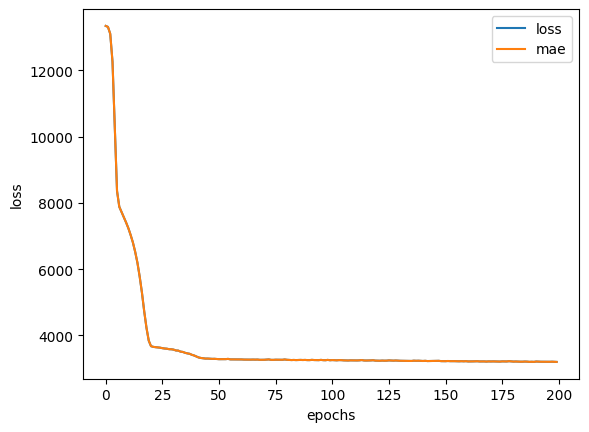

In [105]:
# Plotting loss curve of insurance_model_5
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")